In [16]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
%pip install osmnx networkx
%pip install plotly -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import osmnx as ox      # Responsável por se conectar ao OpenStreetMap, baixar os dados reais da malha viária e extrair as coordenadas geográficas (latitude/longitude).
import networkx as nx   # Responsável por toda a "matemática" do projeto: cria a estrutura de dados do grafo e calcula as métricas exigidas (grau, hubs, betweenness e k-core).
import plotly.graph_objects as go
import matplotlib.pyplot as plt


In [19]:
# CÉLULA 2: DOWNLOAD DA MALHA VIÁRIA E PREPARAÇÃO
place = "Capim Macio, Natal, Rio Grande do Norte, Brazil"

# Baixando o grafo focado apenas em vias para veículos
print("Baixando o grafo. Isso pode levar alguns segundos...")
G = ox.graph_from_place(place, network_type="drive")

# Convertendo para grafo não-direcionado simples (Garante compatibilidade com o k-core)
# Usando a conversão nativa do NetworkX para evitar erros de versão do OSMnx
G_undirected = nx.Graph(G)

print(f"Grafo extraído com sucesso!")
print(f"Total de Nós (pontos): {G_undirected.number_of_nodes()}")
print(f"Total de Arestas (ruas): {G_undirected.number_of_edges()}")

Baixando o grafo. Isso pode levar alguns segundos...
Grafo extraído com sucesso!
Total de Nós (pontos): 639
Total de Arestas (ruas): 997


In [20]:
# Conversão para grafo não direcionado
#G_undirected = ox.convert.to_undirected(G)

# Grau dos nós
degree_dict = dict(G_undirected.degree())
# Top 10 nós por grau
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_degree

# Betweenness e Closeness Centrality
betweenness = nx.betweenness_centrality(G_undirected, normalized=True)
closeness = nx.closeness_centrality(G_undirected) 

# Exemplo de cálculo do core number
# 2. Remove os self-loops (laços de um nó para ele mesmo)
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

core_number = nx.core_number(G_undirected)
# Maior valor de core encontrado
max_core = max(core_number.values())
print(f"Maior core number: {max_core}")
# Nós pertencentes ao núcleo mais denso
main_core_nodes = [node for node, core in core_number.items() if core == max_core]
print(f"Número de nós no núcleo principal: {len(main_core_nodes)}")


Maior core number: 2
Número de nós no núcleo principal: 614


In [21]:
# Adicionando os atributos calculados aos nós do grafo
nx.set_node_attributes(G_undirected, degree_dict, "degree")
nx.set_node_attributes(G_undirected, betweenness, "betweenness")
nx.set_node_attributes(G_undirected, closeness, "closeness")
nx.set_node_attributes(G_undirected, core_number, "core_number")

In [22]:
# exportação do grafo para o gephi

# CÉLULA DE EXPORTAÇÃO CORRIGIDA

# 1. Transformar todos os atributos dos NÓS em texto
for node, data in G_undirected.nodes(data=True):
    for key, value in data.items():
        data[key] = str(value)

# 2. Transformar todos os atributos das ARESTAS (ruas) em texto
for u, v, data in G_undirected.edges(data=True):
    for key, value in data.items():
        data[key] = str(value)

# 3. Agora sim, exportar o arquivo "limpo" para o Gephi
nx.write_graphml(G_undirected, "rede_capim_macio.graphml")

print("Arquivo salvo com sucesso e pronto para o Gephi!")

Arquivo salvo com sucesso e pronto para o Gephi!


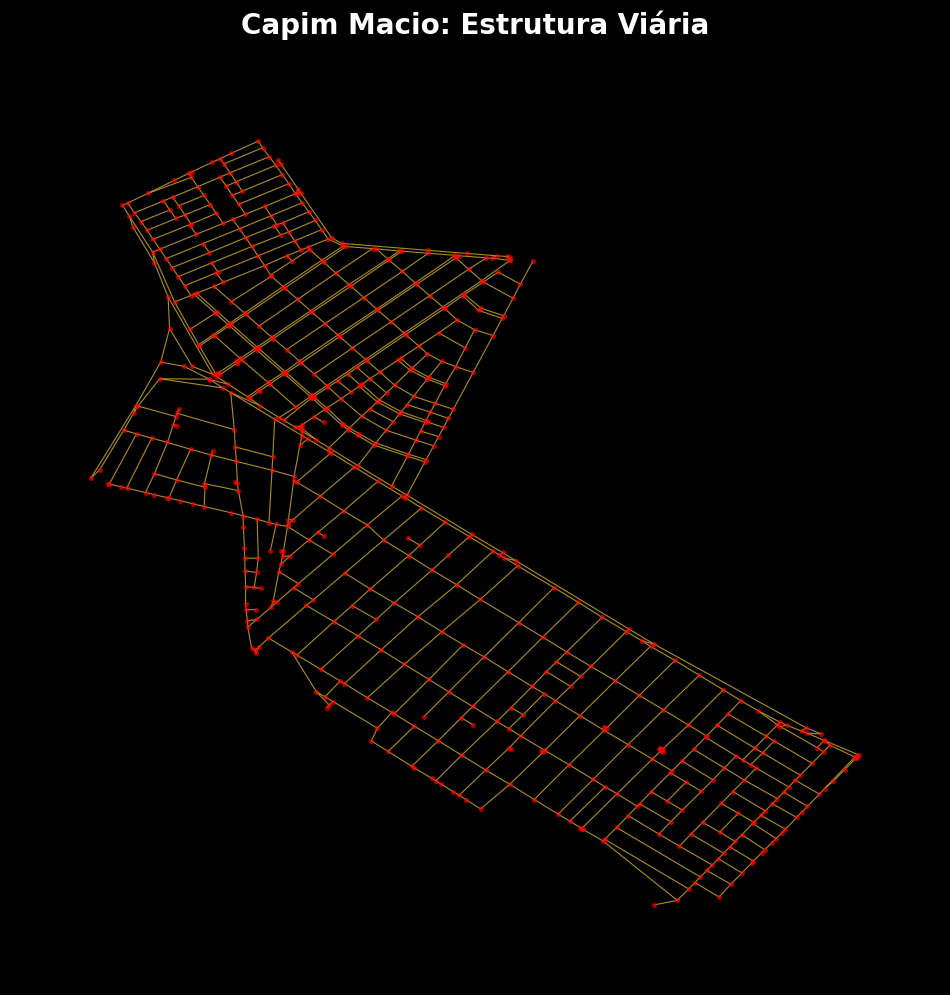

In [23]:
# Extraindo as posições dos nós para o layout geográfico
# pos = {node: (data['x'], data['y']) for node, data in G_undirected.nodes(data=True)}
# Extraindo as posições e forçando a conversão de texto para número (float)
pos = {node: (float(data['x']), float(data['y'])) for node, data in G_undirected.nodes(data=True)}

# 2. Configurar a figura
fig, ax = plt.subplots(figsize=(12, 12))
fig.set_facecolor("#000000")  # Cor de fundo suave
ax.set_facecolor("#000000")  # Cor de fundo suave

# 3. Desenhar as arestas (ruas)
nx.draw_networkx_edges(
    G_undirected, 
    pos, 
    ax=ax, 
    edge_color='#D4AF37',  # Código Hex para Dourado (Gold)
    width=0.8, 
    alpha=0.8,             # Leve transparência para dar sofisticação
    arrows=False
)

# 4. Desenhar os nós (pontos/interseções) - Opcional
# Aqui deixamos pequenos para não poluir
nx.draw_networkx_nodes(
    G_undirected, 
    pos, 
    ax=ax, 
    node_size=8,           # Tamanho pequeno para não esconder as ruas
    alpha=0.5,
    node_color='#FF0000'   # Vermelho Puro
)

# 5. Ajustes estéticos finais
ax.set_title("Capim Macio: Estrutura Viária", color='white', fontsize=20, fontweight='bold', pad=20)
ax.set_axis_off()          # Remove as bordas e números dos eixos

# 6. Salvar em alta definição
plt.savefig("mapa_custom.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

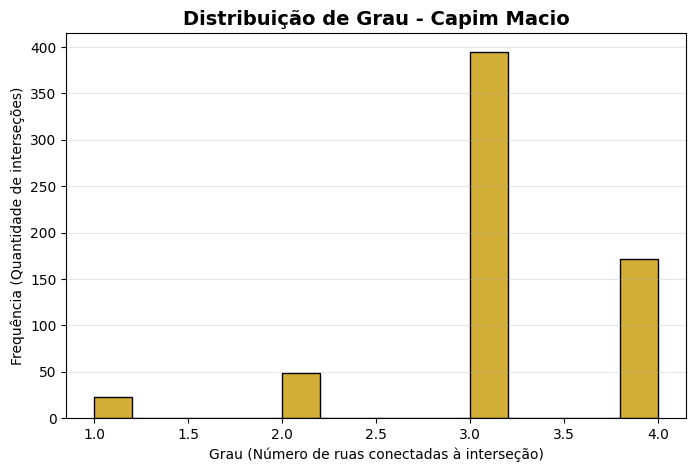

In [24]:
# Plotando a Distribuição de Grau
graus = [grau for no, grau in degree_dict.items()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(graus, bins=15, color='#D4AF37', edgecolor='black')
ax.set_title("Distribuição de Grau - Capim Macio", fontsize=14, fontweight='bold')
ax.set_xlabel("Grau (Número de ruas conectadas à interseção)")
ax.set_ylabel("Frequência (Quantidade de interseções)")
ax.grid(axis='y', alpha=0.3)

plt.show()